In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


# 1. Univariate Analysis

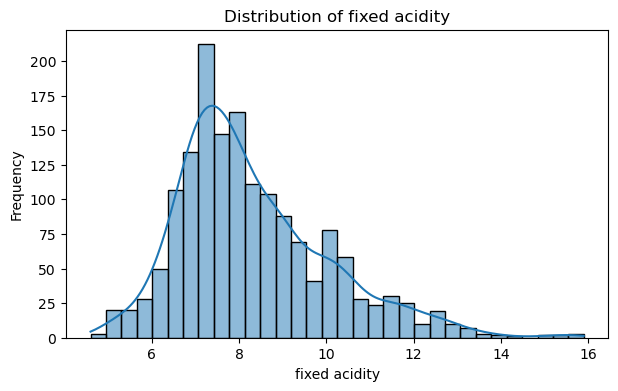

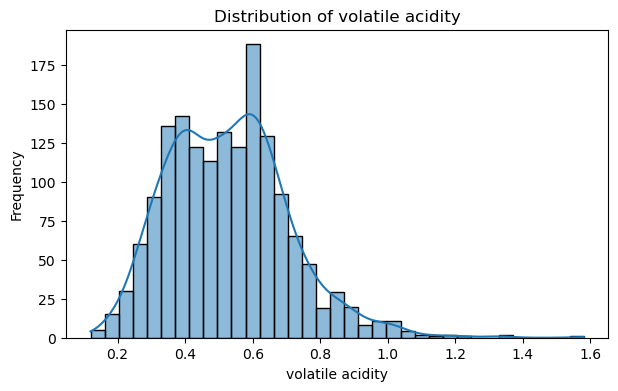

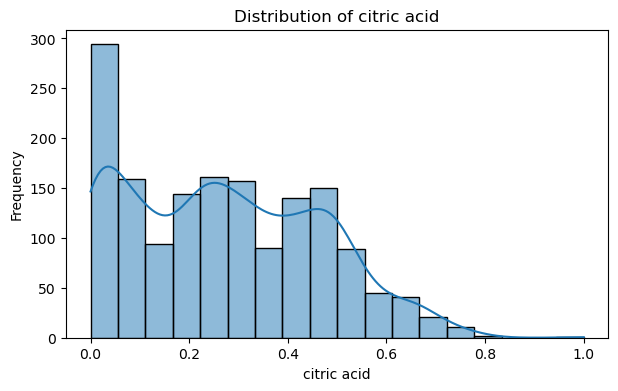

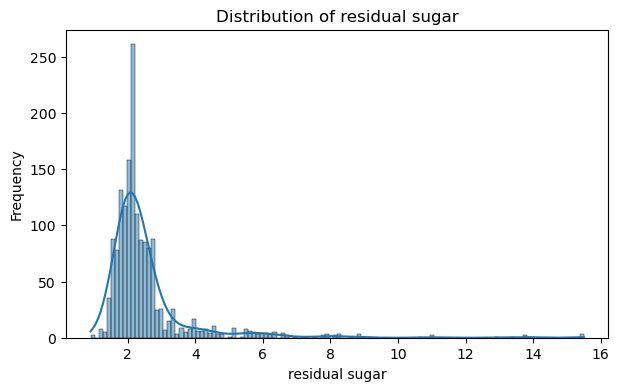

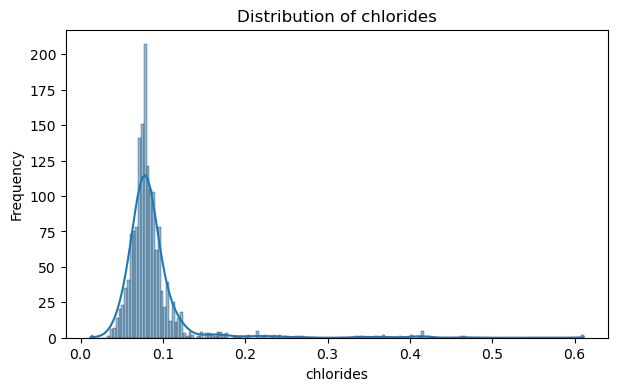

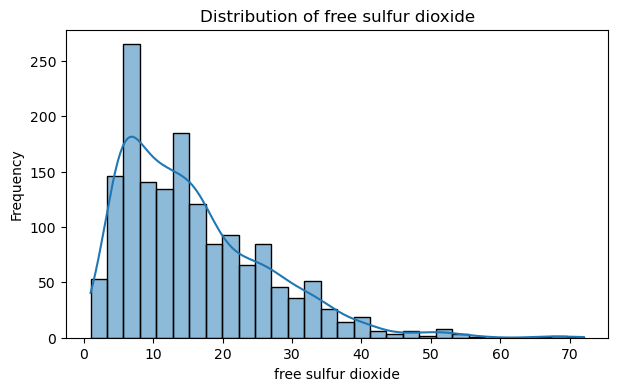

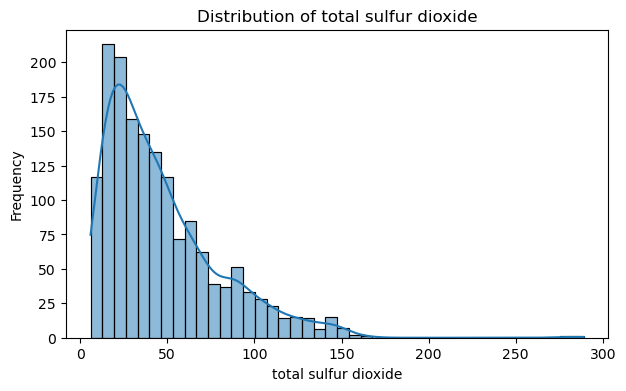

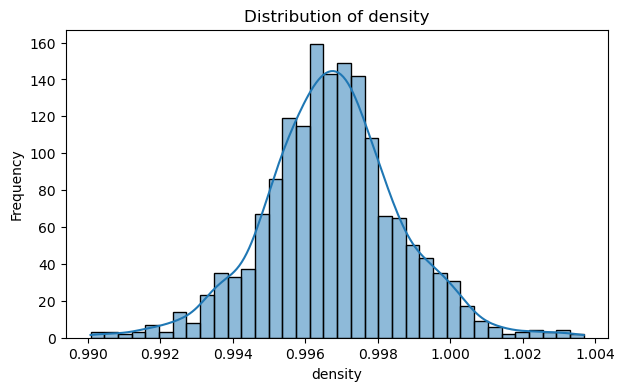

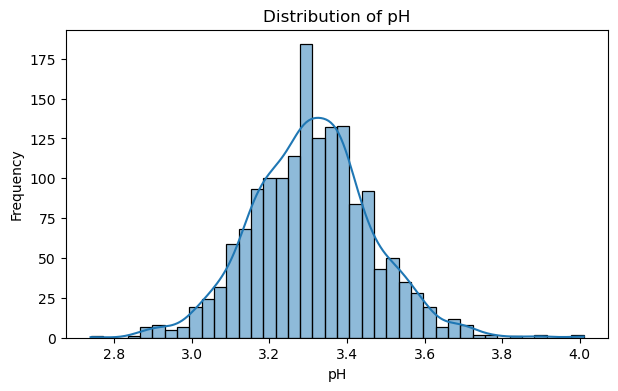

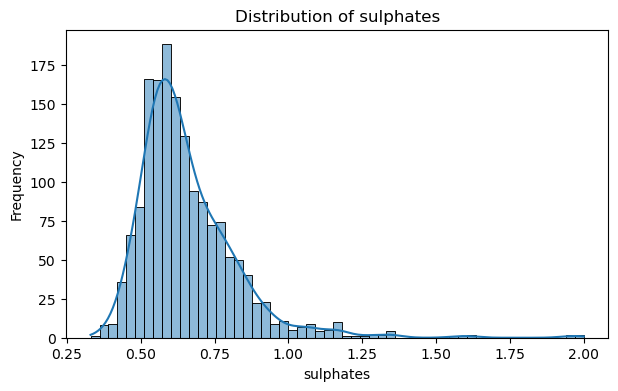

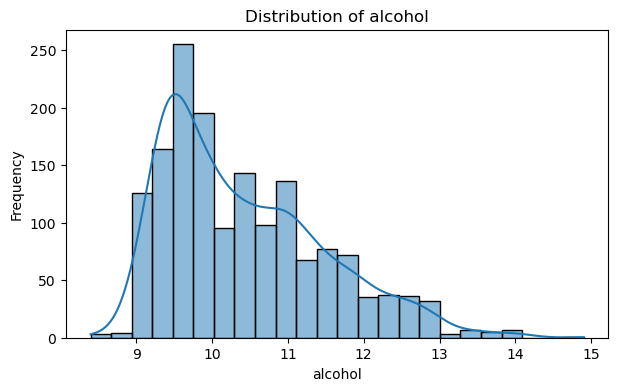

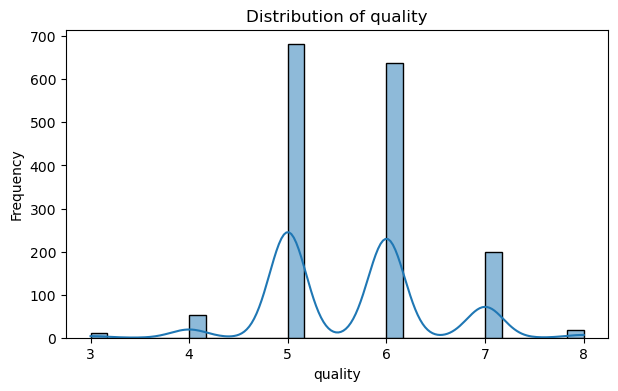

In [6]:
#Histogram + KDE
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.columns

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

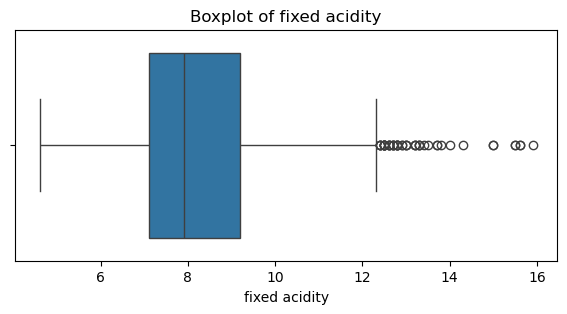

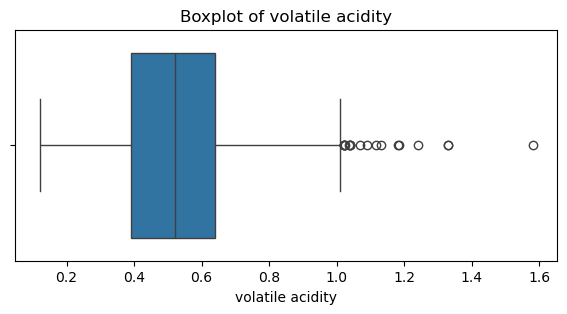

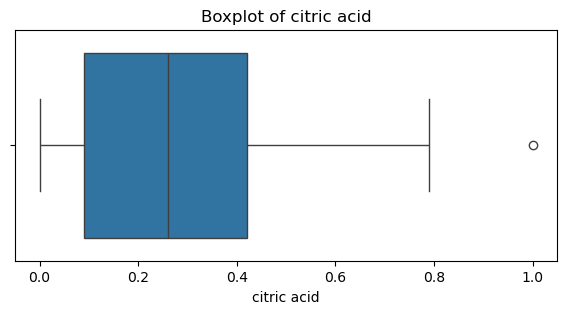

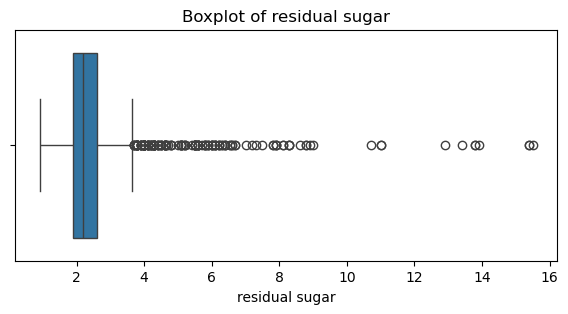

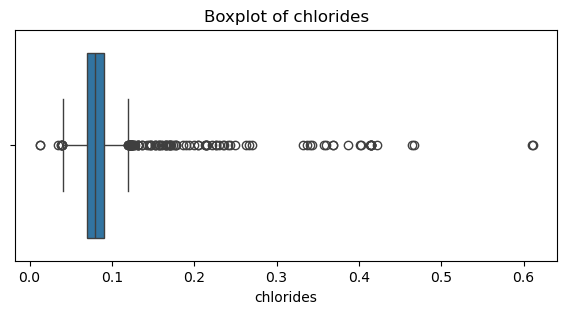

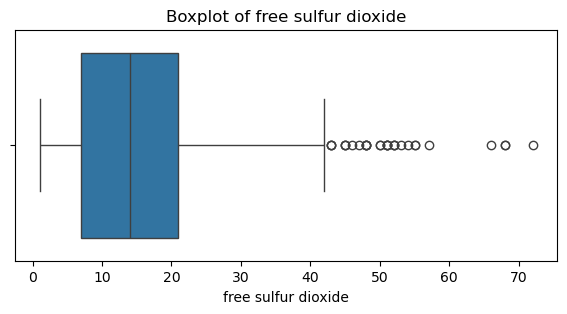

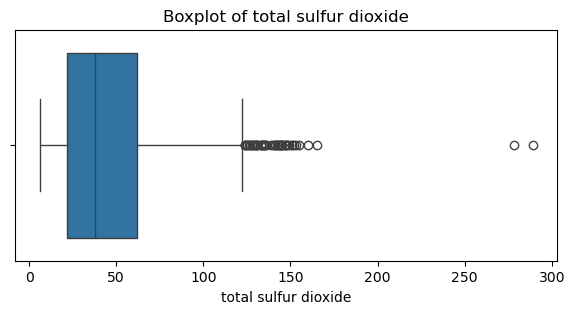

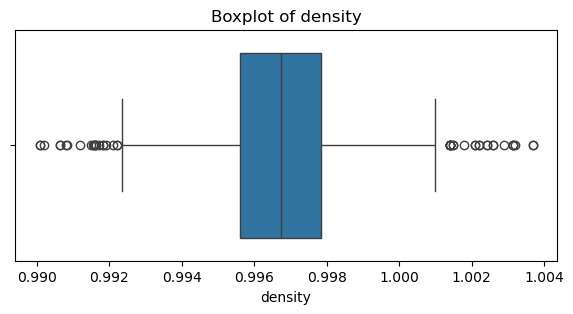

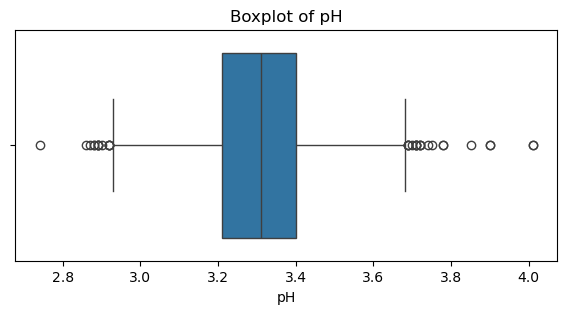

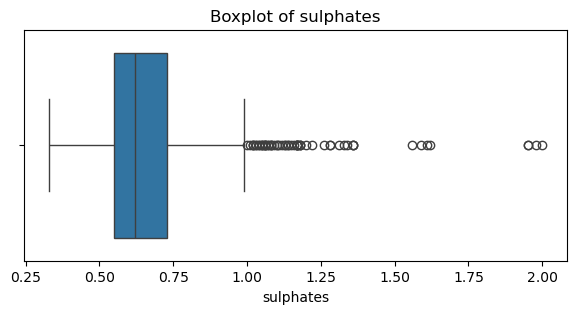

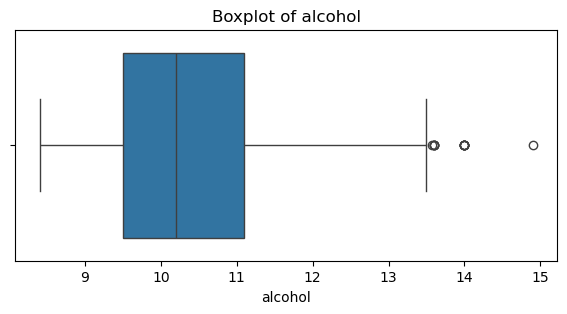

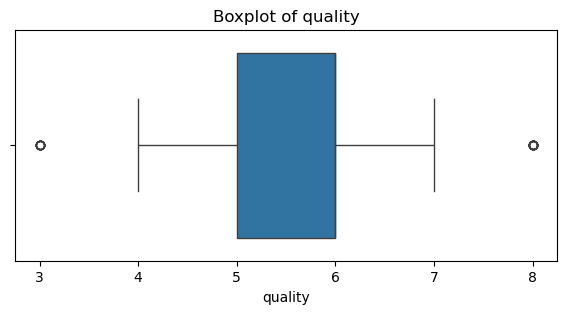

In [7]:
#Boxplot - Outlier Analysis
for col in numeric_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

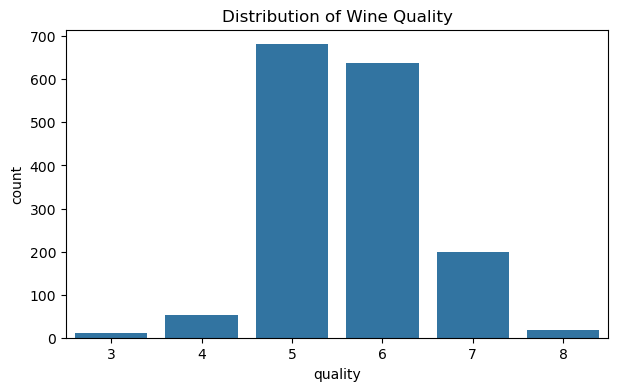

In [8]:
#Quality Distribution
plt.figure(figsize=(7,4))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality')
plt.show()

# 2. Bivariate Analysis

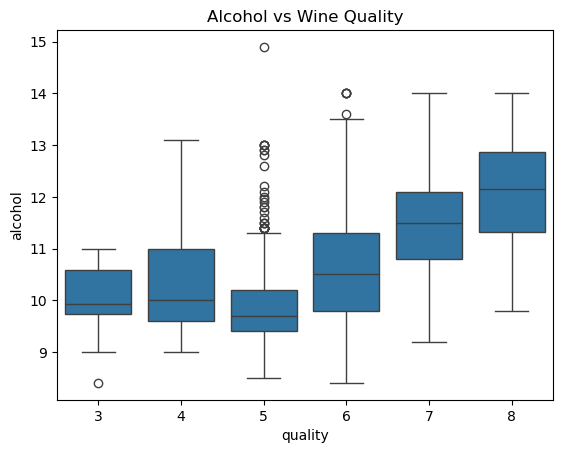

In [10]:
#Alcohol vs Quality
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol vs Wine Quality')
plt.show()

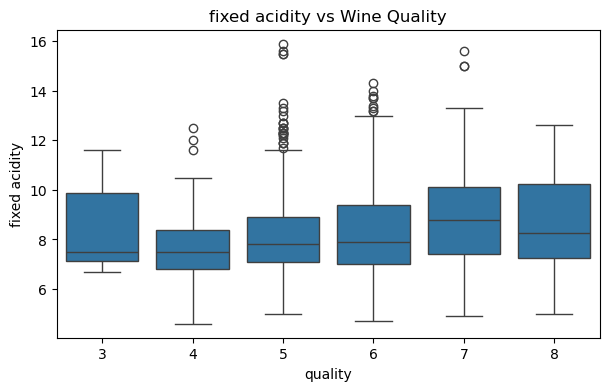

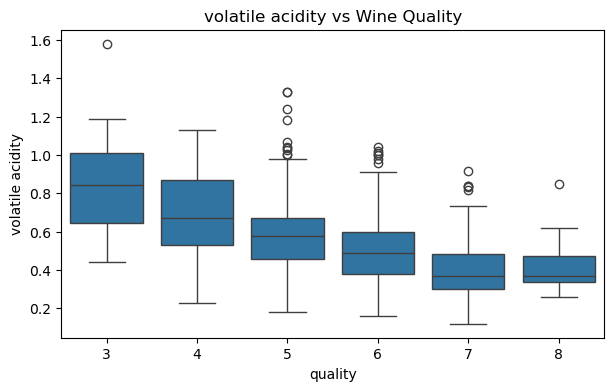

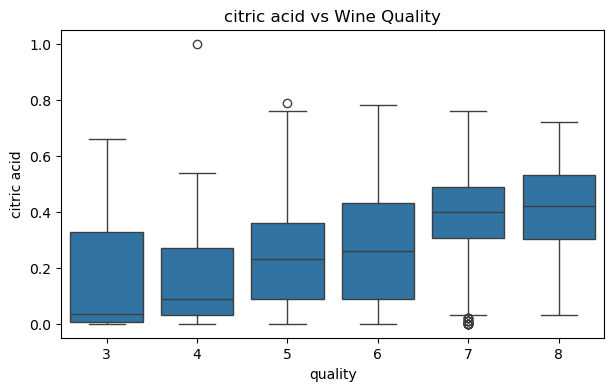

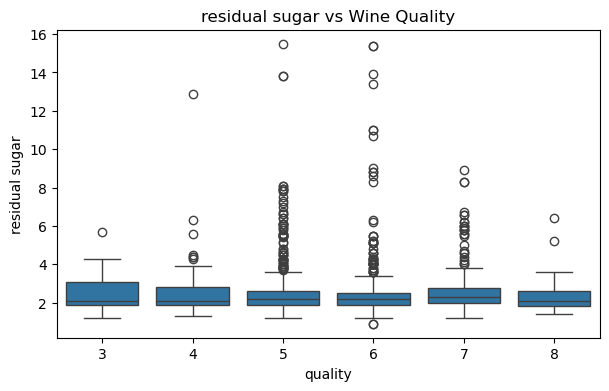

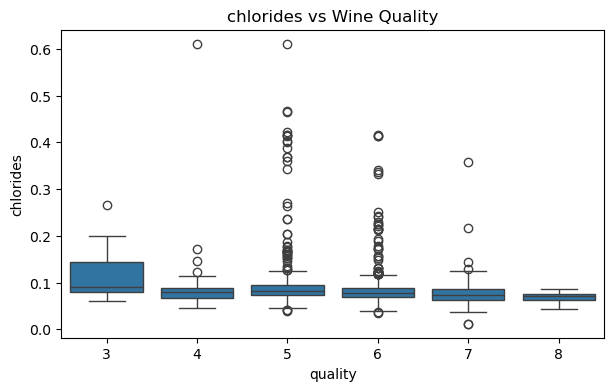

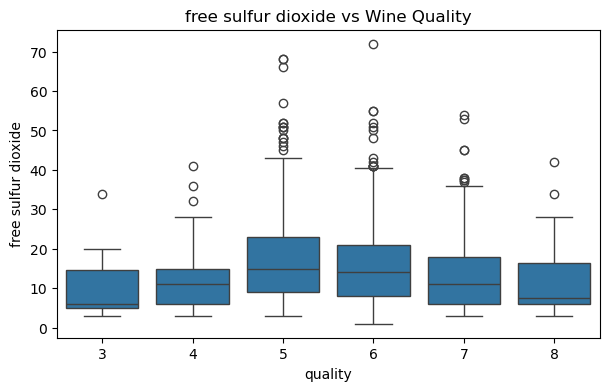

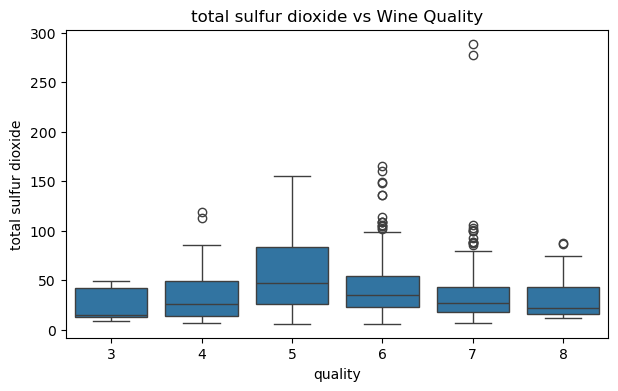

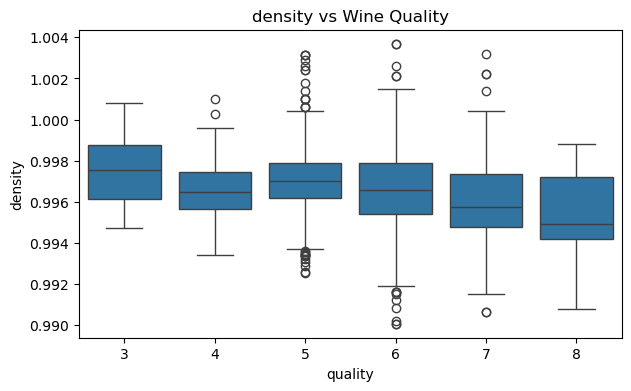

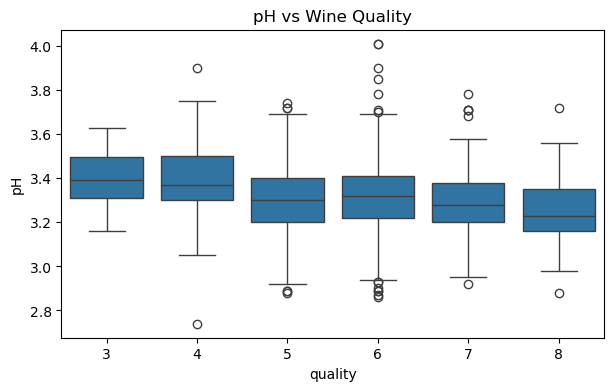

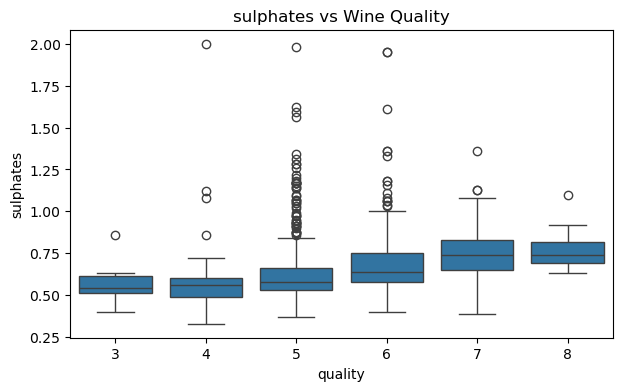

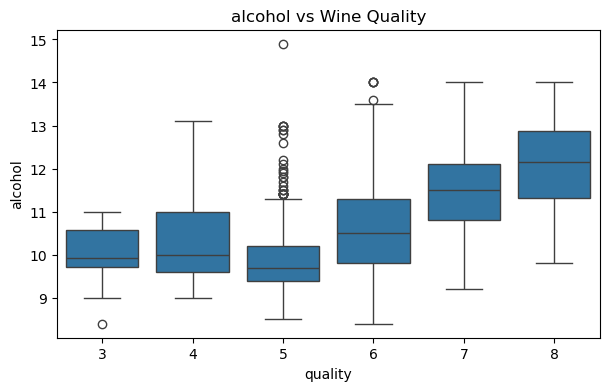

In [11]:
features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

for col in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='quality', y=col, data=df)
    plt.title(f'{col} vs Wine Quality')
    plt.show()

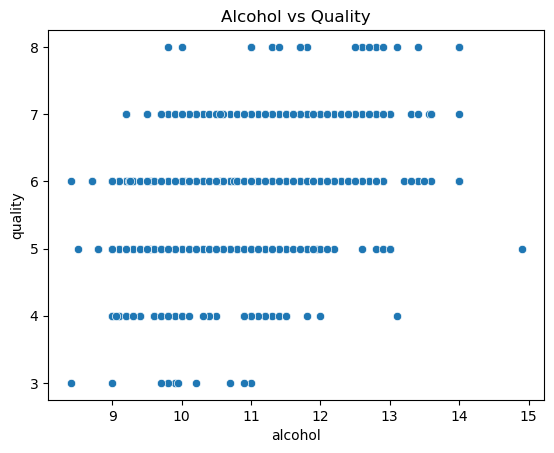

In [12]:
#Scatter Plot
sns.scatterplot(x='alcohol', y='quality', data=df)
plt.title('Alcohol vs Quality')
plt.show()

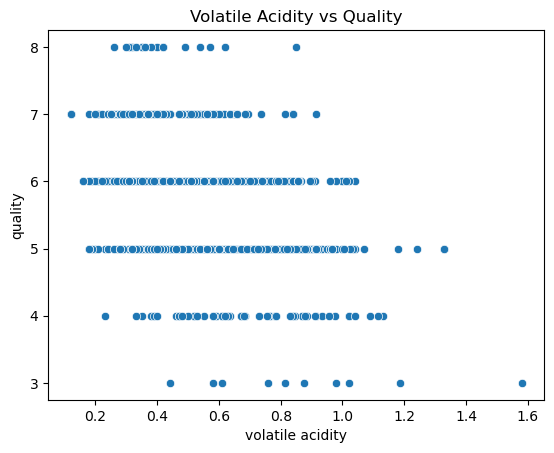

In [13]:
sns.scatterplot(x='volatile acidity', y='quality', data=df)
plt.title('Volatile Acidity vs Quality')
plt.show()

# 3. Multivariate Analysis

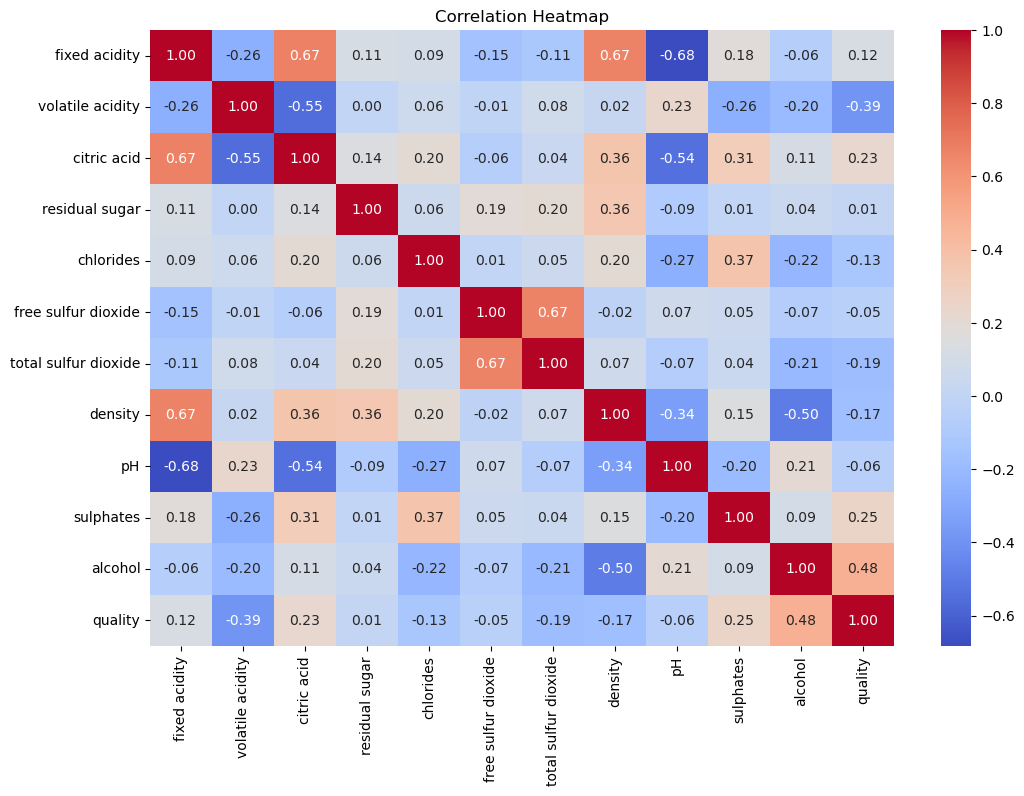

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr,annot=True, cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

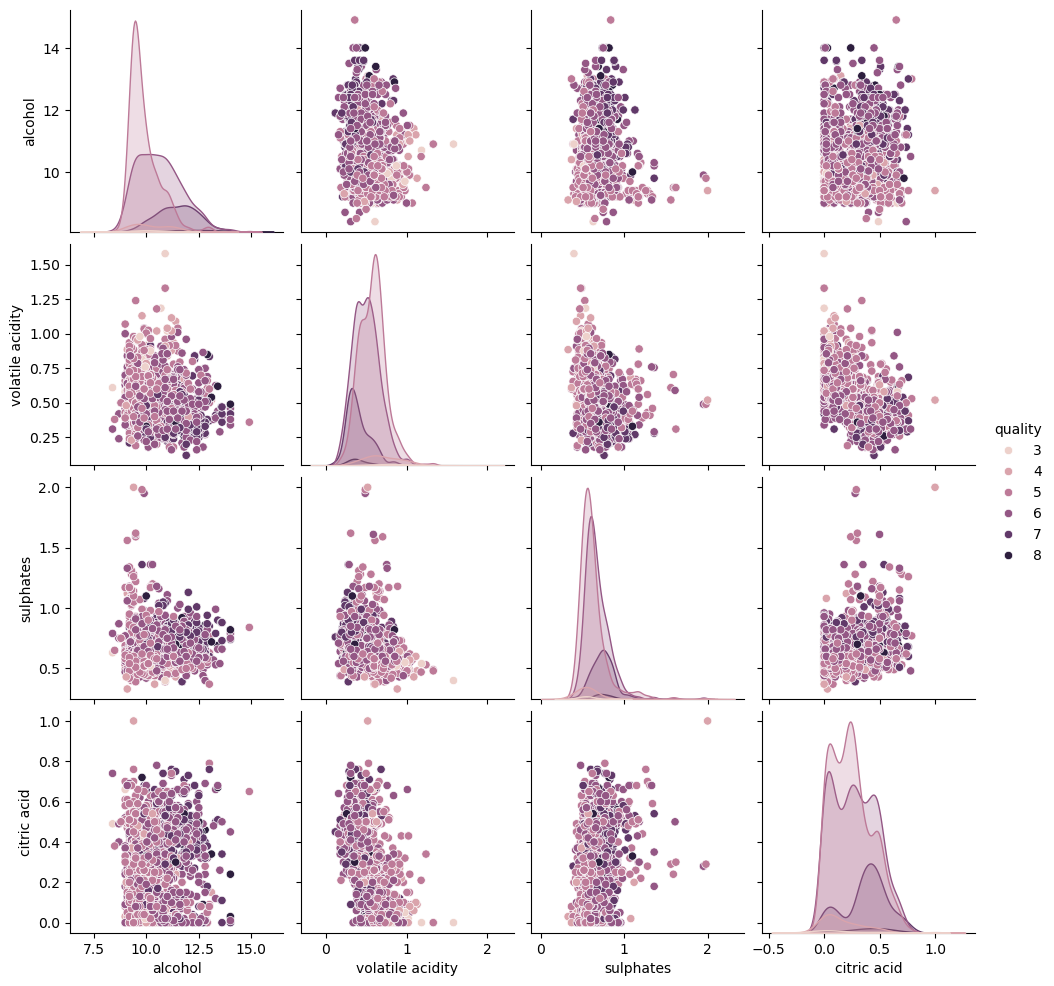

In [16]:
#Pair Plot
selected = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']

sns.pairplot(df[selected], hue='quality')

plt.show()

In [17]:
#Multivariate Analysis Using Quality Groups
df['quality_group'] = pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels = ['Low', 'Medium', 'High']
)

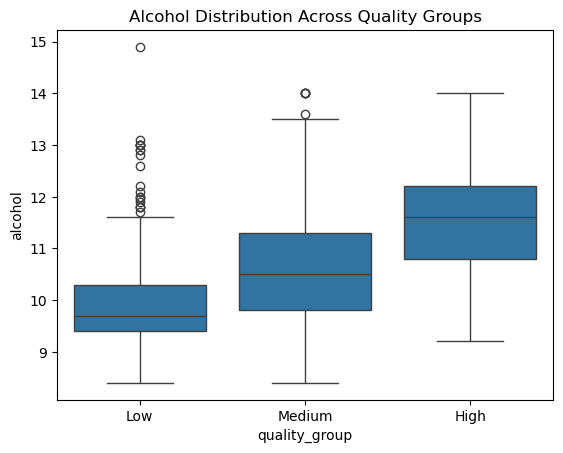

In [18]:
sns.boxplot(
    x='quality_group',
    y='alcohol',
    data=df
)

plt.title('Alcohol Distribution Across Quality Groups')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, classification_report,
                            confusion_matrix, ConfusionMatrixDisplay)

In [20]:
X = df.drop('quality', axis=1)
y = df['quality']

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599, 12)
y shape: (1599,)


In [22]:
print(y.value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,
        random_state=42,
        stratify=y
)

In [24]:
criterion='entropy'

In [25]:
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

In [26]:
df['quality_group'] = pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels = ['Low', 'Medium', 'High']
)

In [27]:
print(X.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality_group'],
      dtype='object')


In [28]:
print(X.select_dtypes(exclude='number').columns)

Index(['quality_group'], dtype='object')


In [29]:
y = df['quality']

In [30]:
X = df.drop(columns=['quality', 'quality_group'], errors='ignore')

In [31]:
print(X.columns)
print(X.dtypes)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,
        random_state=42,
        stratify=y
)

In [33]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1279, 11)
X_test: (320, 11)
y_train: (1279,)
y_test: (320,)


In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [35]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [36]:
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

In [37]:
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


In [38]:
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.59375


In [39]:
print("Precision:",
     precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:",
     recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:",
     f1_score(y_test, y_test_pred, average='weighted'))

Precision: 0.5899604951771574
Recall: 0.59375
F1 Score: 0.5912882260970955


In [40]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.11      0.09      0.10        11
           5       0.66      0.64      0.65       136
           6       0.58      0.62      0.60       128
           7       0.53      0.53      0.53        40
           8       0.50      0.33      0.40         3

    accuracy                           0.59       320
   macro avg       0.40      0.37      0.38       320
weighted avg       0.59      0.59      0.59       320



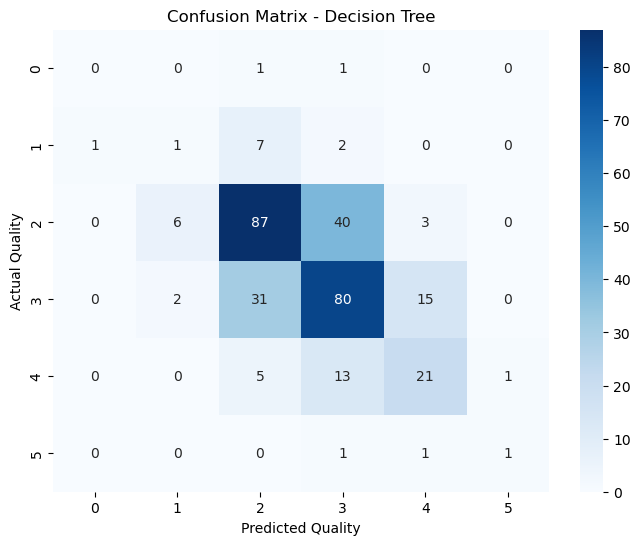

In [41]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('Confusion Matrix - Decision Tree')

plt.show()

In [42]:
print("Tree Depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Tree Depth: 19
Number of leaves: 297


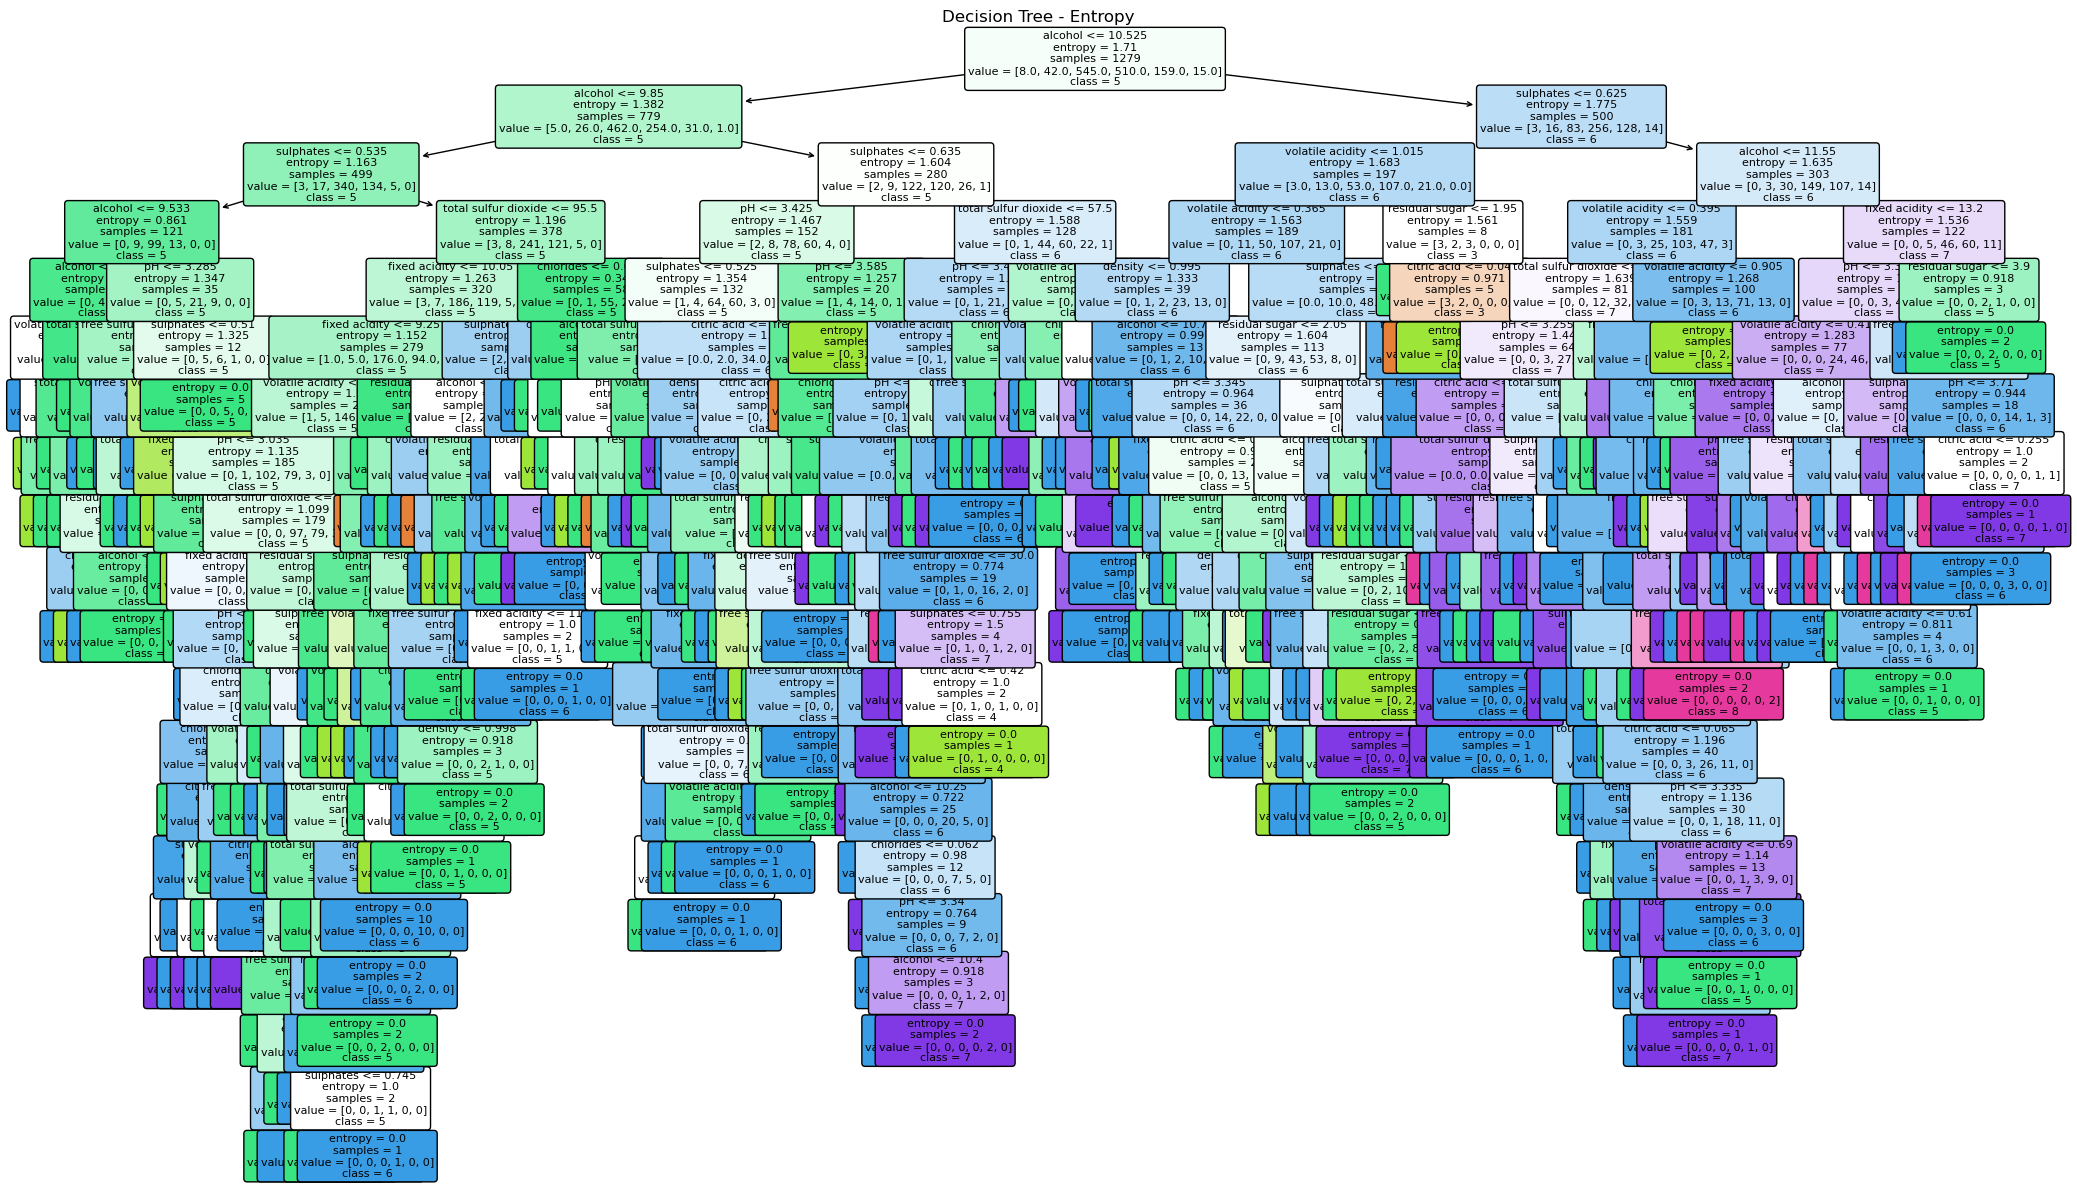

In [43]:
plt.figure(figsize=(25, 15))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Entropy")
plt.show()

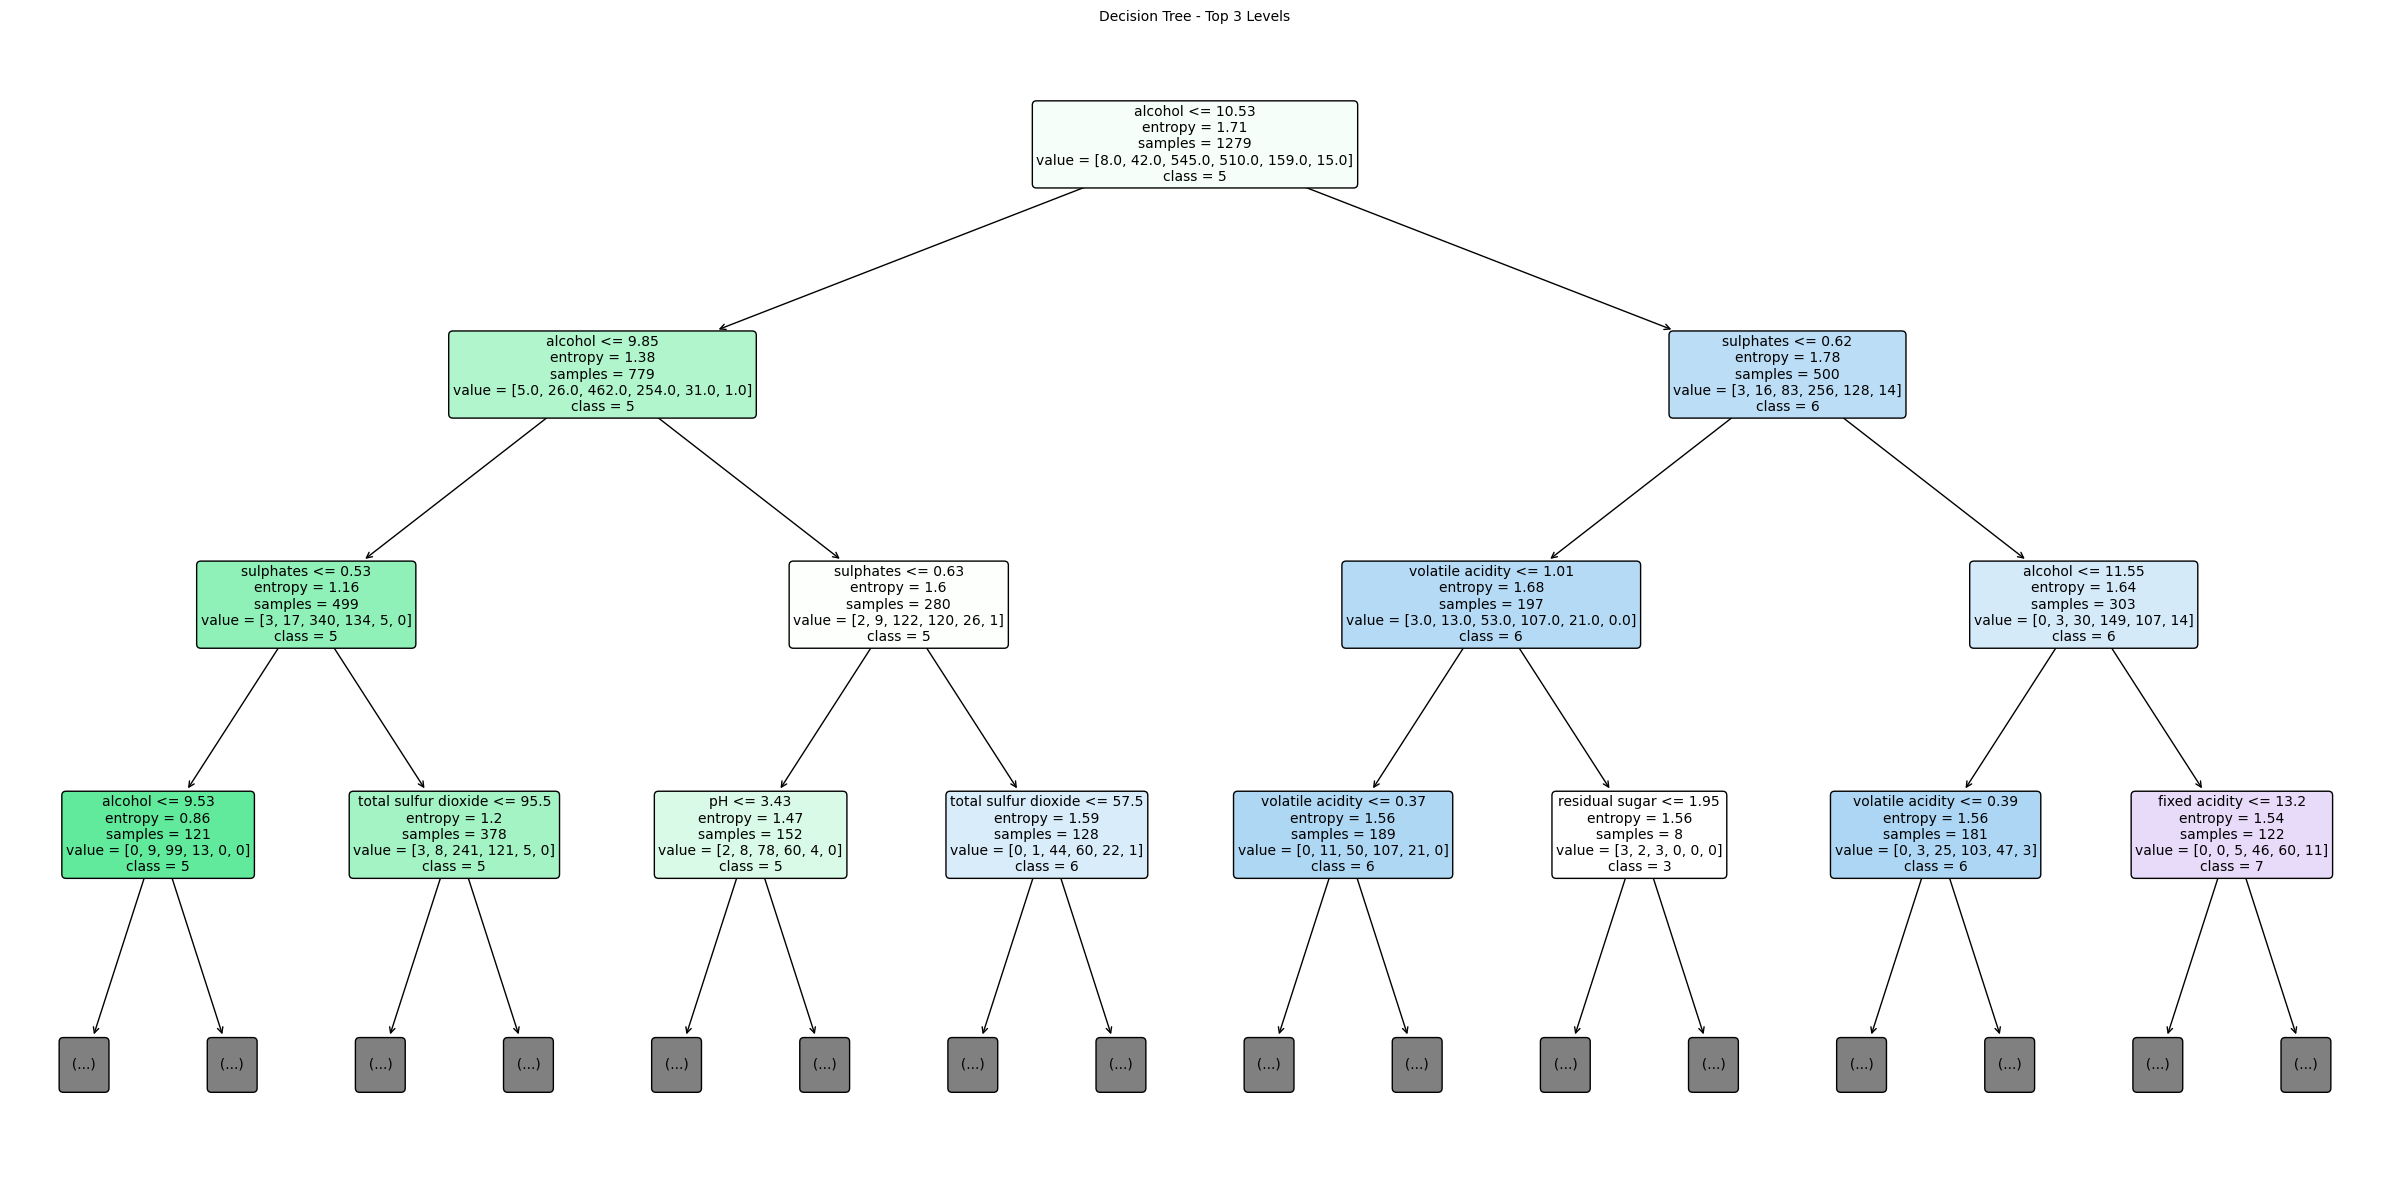

In [44]:
plt.figure(figsize=(24,12))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree - Top 3 Levels",fontsize=10)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

param_grid= {
    'criterion':['entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,4,8],
    'max_features':[None,'sqrt','log2'],
    'ccp_alpha':[0,0.001,0.005,0.01]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
                   cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Parameters")
print(grid.best_params_)

print("Best Cross Validation Accuracy")
print(grid.best_score)
